In [ ]:
!pip install earthkit-data earthkit-plots xarray pandas netCDF4 cdsapi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 813.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.0/556.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.1/41.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.6 M

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import earthkit.data

caminho_arquivo = '/content/drive/MyDrive/Dados_ERA5/dados_25era' # Adicione .grib no final se o arquivo tiver essa extensão

fonte = earthkit.data.from_source("file", caminho_arquivo)

dados = fonte.to_fieldlist()

dados.ls()
!pip install cartopy

In [ ]:
# 1. Converte TUDO diretamente para Xarray (sem filtrar antes)
ds = dados.to_xarray()

# 2. Imprime a estrutura do arquivo para descobrirmos os nomes
print("Estrutura do arquivo:")
print(ds)

Estrutura do arquivo:
<xarray.Dataset> Size: 97MB
Dimensions:                  (forecast_reference_time: 372, latitude: 116,
                              longitude: 141)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 3kB 199...
  * latitude                 (latitude) float64 928B -14.0 -14.1 ... -25.4 -25.5
  * longitude                (longitude) float64 1kB -53.5 -53.4 ... -39.6 -39.5
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 49MB ...
    tp                       (forecast_reference_time, latitude, longitude) float64 49MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF


In [ ]:
# 1. Filtra para o ano de 2024 usando a dimensão CORRETA que vimos na imagem
ds_2024 = ds.sel(forecast_reference_time=slice('2024-01-01', '2024-12-31'))

# 2. Isola apenas a variável de Temperatura (2t) para não pesar o arquivo à toa
ds_temp_2024 = ds_2024[['2t']]

print("Dados de 2024 filtrados com sucesso!")

# 3. Converte para DataFrame do Pandas e remove dados nulos (NaN)
df_2024 = ds_temp_2024.to_dataframe().reset_index().dropna()

# 4. Salva no Google Drive em formato Parquet
caminho_parquet = '/content/drive/MyDrive/Dados_ERA5/era5_temperatura_2024.parquet'
df_2024.to_parquet(caminho_parquet, index=False)

print(f"Arquivo salvo com sucesso em: {caminho_parquet}")

Dados de 2024 filtrados com sucesso!
Arquivo salvo com sucesso em: /content/drive/MyDrive/Dados_ERA5/era5_temperatura_2024.parquet


In [ ]:
import numpy as np
import xarray as xr

# 1. Calcular a Climatologia Mensal (Média de 1996 a 2025)
# Usando o nome EXATO da sua dimensão de tempo
ds_clima = ds.groupby('forecast_reference_time.month').mean('forecast_reference_time')

# 2. Ajuste de Unidades (CRUCIAL)
# Temperatura de Kelvin para Celsius
T = ds_clima['2t'] - 273.15

# Precipitação (ERA5 costuma dar em metros, multiplicamos por 1000 para mm)
P = ds_clima['tp'] * 1000

# 3. Variáveis base do Algoritmo de Köppen (Alvares et al., 2013)
T_ann = T.mean(dim='month')
T_hot = T.max(dim='month')
T_cold = T.min(dim='month')
T_m10 = (T > 10).sum(dim='month')

P_ann = P.sum(dim='month')
P_dry = P.min(dim='month')

# Filtros de Verão (Out-Mar) e Inverno (Abr-Set) no Hemisfério Sul
P_summer = P.sel(month=[1, 2, 3, 10, 11, 12])
P_winter = P.sel(month=[4, 5, 6, 7, 8, 9])

P_sdry = P_summer.min(dim='month')
P_wdry = P_winter.min(dim='month')
P_swet = P_summer.max(dim='month')
P_wwet = P_winter.max(dim='month')

# 4. Construção da Lógica Vetorizada (Rápida e sem loops)
# Inicializamos uma matriz vazia com o mesmo formato do mapa (lat, lon)
koppen_map = xr.zeros_like(T_ann)

# --- REGRAS PARA CLIMA A (Tropical) ---
is_A = T_cold >= 18
is_Af = is_A & (P_dry >= 60)
is_Am = is_A & (P_dry < 60) & (P_ann >= 25 * (100 - P_dry))
is_Aw = is_A & (P_dry < 60) & (P_ann < 25 * (100 - P_wdry))
is_As = is_A & (P_dry < 60) & (P_ann < 25 * (100 - P_sdry))

# --- REGRAS PARA CLIMA C (Subtropical) ---
is_C = (T_cold >= -3) & (T_cold < 18)
is_Cw = is_C & (P_swet >= 10 * P_wdry)
is_Cs = is_C & (P_wwet >= 3 * P_sdry) & (P_dry < 40)
is_Cf = is_C & ~is_Cw & ~is_Cs

# Subtipos de Temperatura para C
is_a = T_hot >= 22
is_b = (T_hot < 22) & (T_m10 >= 4)
is_c = (T_hot < 22) & (T_m10 < 4)

# Combinações Finais do Clima C
is_Cfa = is_Cf & is_a
is_Cfb = is_Cf & is_b
is_Cwa = is_Cw & is_a
is_Cwb = is_Cw & is_b
is_Cwc = is_Cw & is_c
is_Csa = is_Cs & is_a
is_Csb = is_Cs & is_b

# 5. Atribuição de Códigos Numéricos para cada Clima
# Usamos a mesma ordem de legenda do visual planejado
condicoes = [
    is_Af, is_Am, is_Aw, is_As,
    is_Cfa, is_Cfb, is_Cwa, is_Cwb, is_Cwc, is_Csa, is_Csb
]
# Códigos: 0=Af, 1=Am, 2=Aw, 3=As, 4=Cfa, 5=Cfb, 6=Cwa, 7=Cwb, 8=Cwc, 9=Csa, 10=Csb
codigos = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Aplica as condições na matriz
koppen_array = np.select(condicoes, codigos, default=np.nan)

# Salva o resultado de volta em um Xarray Dataset
ds_koppen = xr.Dataset(
    {'classe_climatica': (['latitude', 'longitude'], koppen_array)},
    coords={'latitude': T.latitude, 'longitude': T.longitude}
)

print("Classificação concluída com sucesso!")

Classificação concluída com sucesso!


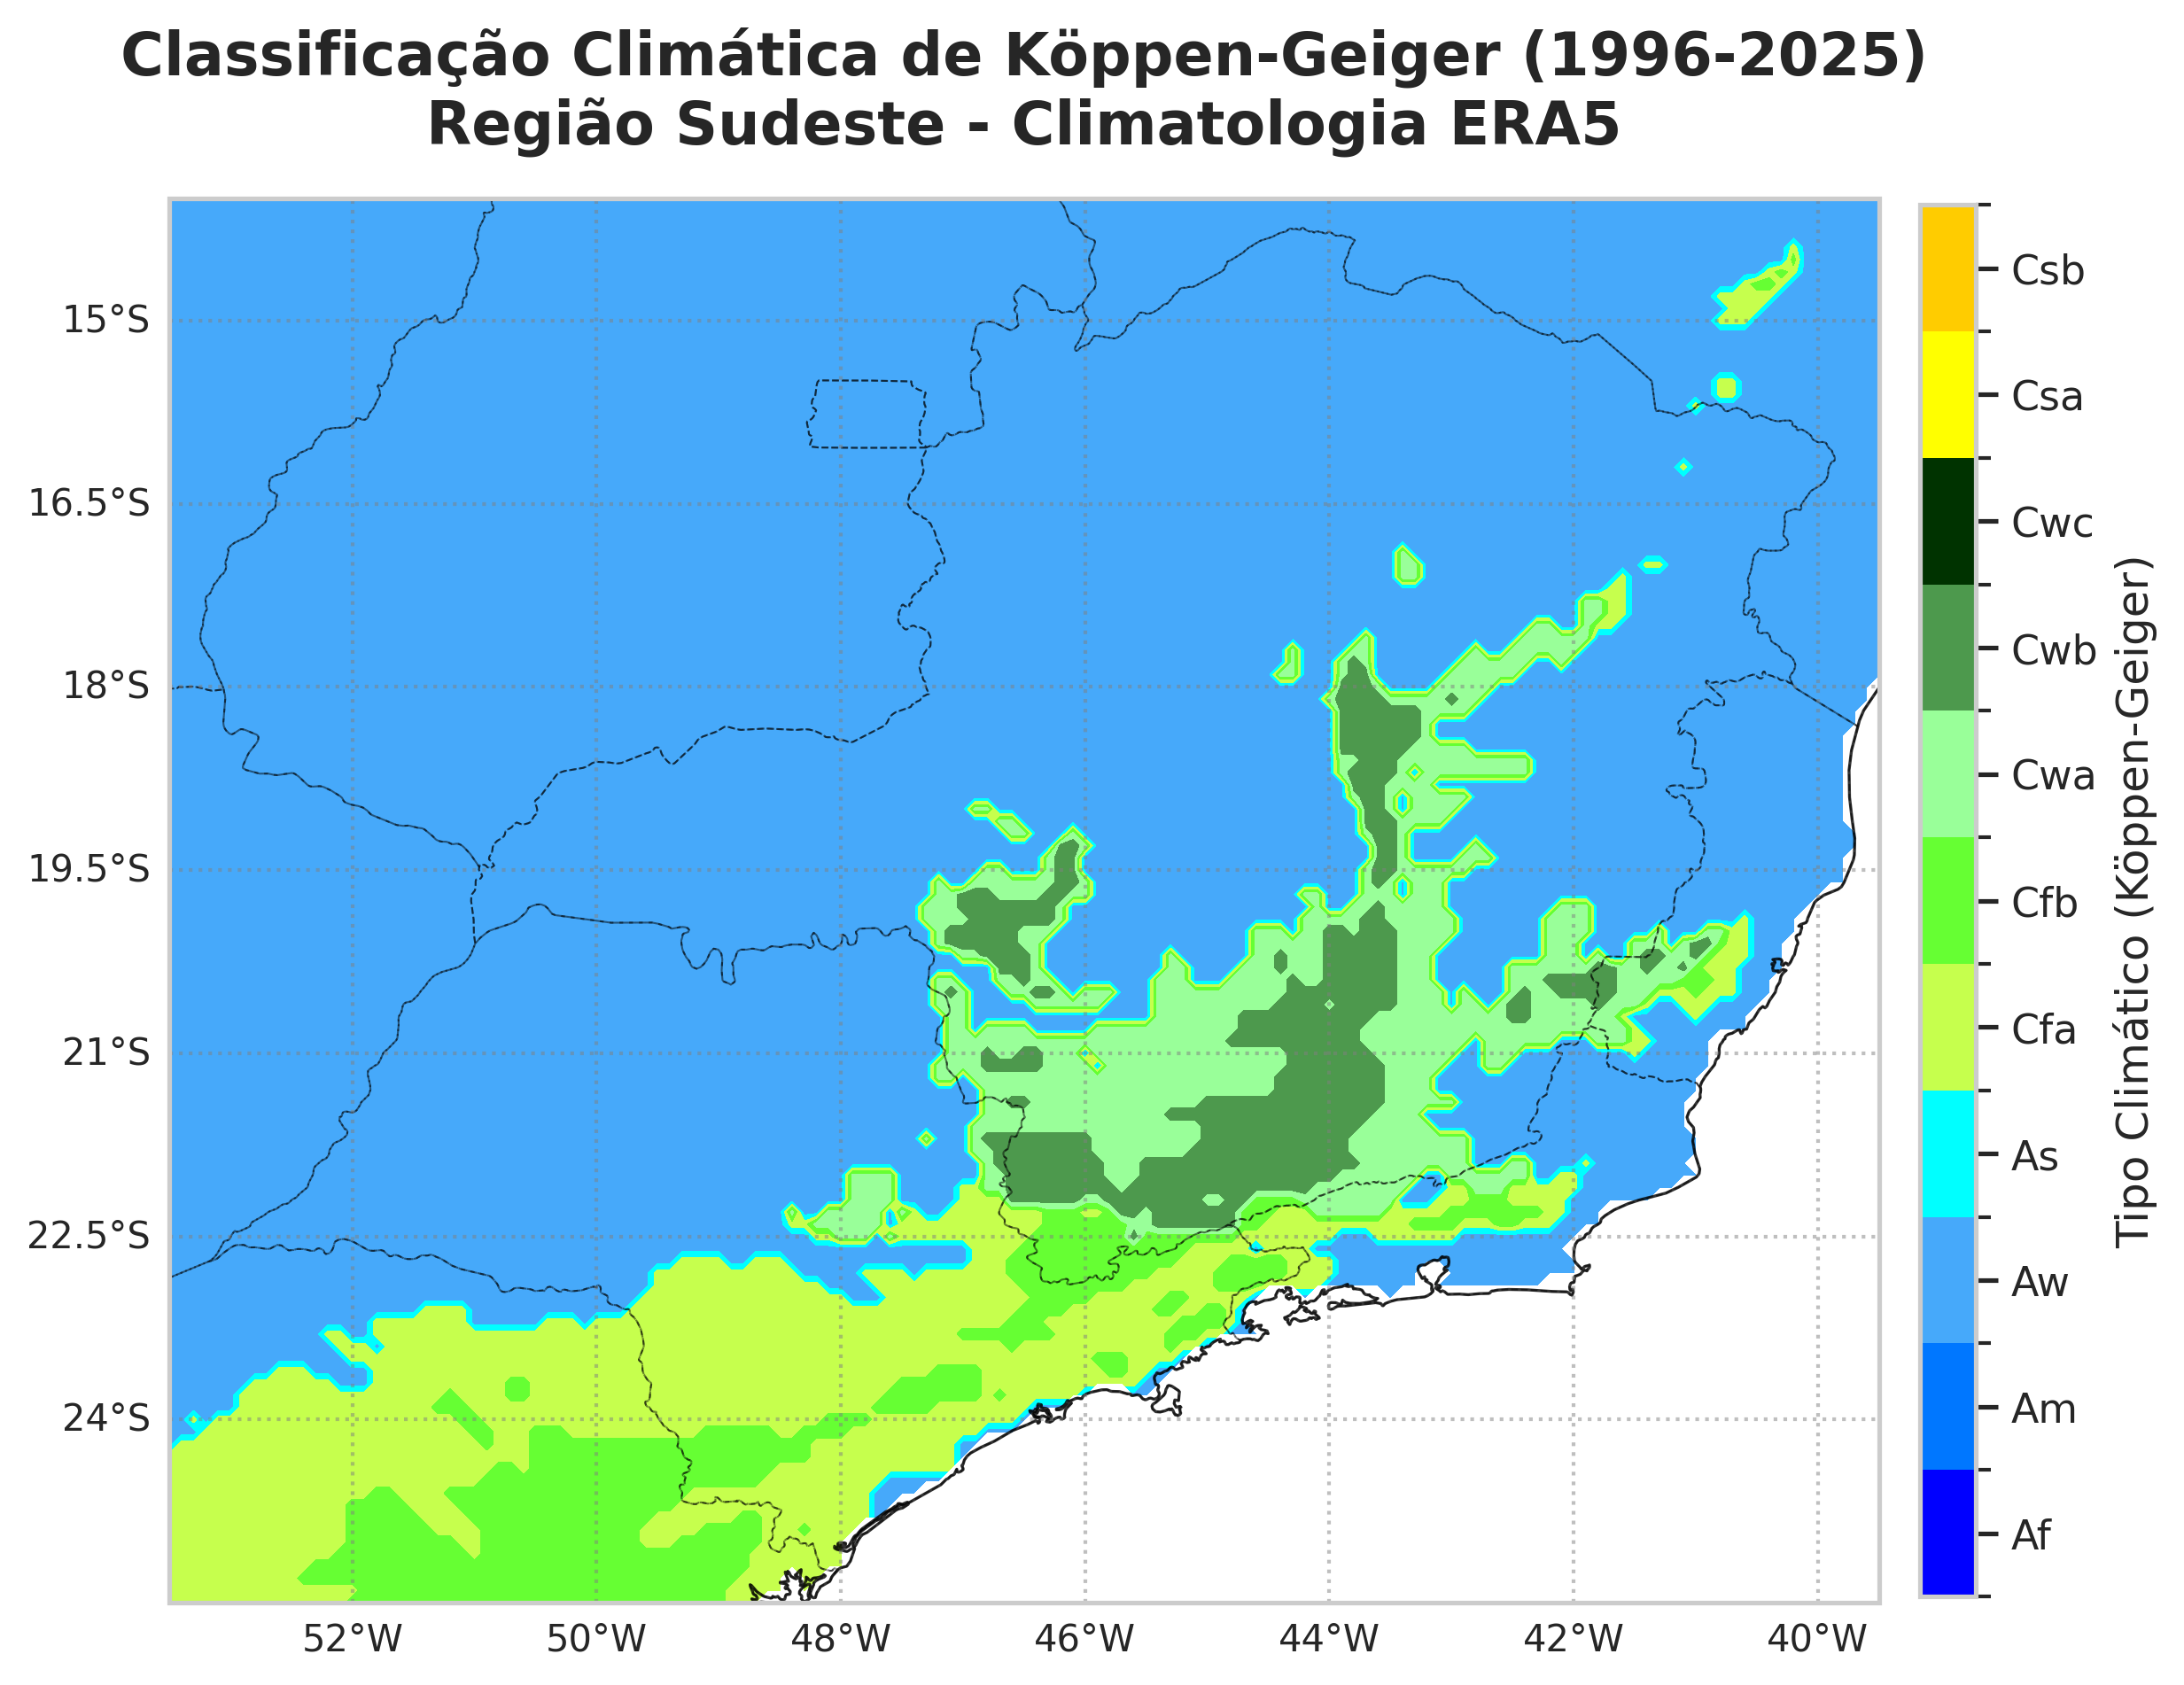

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# 1. Definir paleta de cores para os 11 climas
cores_koppen = [
    '#0000FF', # 0: Af (Azul escuro)
    '#0077FF', # 1: Am (Azul médio)
    '#46A9FA', # 2: Aw (Azul claro)
    '#00FFFF', # 3: As (Ciano)
    '#C6FF4D', # 4: Cfa (Verde-limão)
    '#66FF33', # 5: Cfb (Verde claro)
    '#99FF99', # 6: Cwa (Verde muito claro)
    '#4D994D', # 7: Cwb (Verde escuro)
    '#003300', # 8: Cwc (Verde super escuro)
    '#FFFF00', # 9: Csa (Amarelo)
    '#FFCC00'  # 10: Csb (Amarelo escuro)
]
classes_nomes = ['Af', 'Am', 'Aw', 'As', 'Cfa', 'Cfb', 'Cwa', 'Cwb', 'Cwc', 'Csa', 'Csb']

# Configura o mapa de cores discreto
cmap_koppen = ListedColormap(cores_koppen)
cmap_koppen.set_bad('#E6E6E6')

# 2. Configura a figura com alta resolução (dpi=300)
fig = plt.figure(figsize=(10, 8), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

# TRUQUE DE SUAVIZAÇÃO: Definimos os limites ('levels') exatamente no meio entre cada classe
n_classes = len(cores_koppen)
limites_suaves = np.arange(-0.5, n_classes + 0.5, 1)

# 3. Plota usando contourf com os limites customizados para arredondar as bordas
plot = ds_koppen['classe_climatica'].plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=limites_suaves,
    cmap=cmap_koppen,
    add_colorbar=False # Desativa a legenda padrão
)

# 4. Adiciona as delimitações territoriais (Cartopy)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black', alpha=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black', alpha=0.5, linestyle='--')

# 5. Configura as linhas de grade
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# 6. Adiciona e formata a barra de cores (Legenda)
# Recria a norma de limites apenas para a legenda ficar perfeita
norm = BoundaryNorm(limites_suaves, cmap_koppen.N)
sm = plt.cm.ScalarMappable(cmap=cmap_koppen, norm=norm)
sm.set_array([]) # Necessário para o ScalarMappable funcionar

cbar = fig.colorbar(sm, ax=ax, pad=0.02, aspect=25, shrink=0.85)
cbar.set_ticks(np.arange(n_classes))
cbar.set_ticklabels(classes_nomes)
cbar.set_label('Tipo Climático (Köppen-Geiger)', fontsize=12)

# 7. Título do mapa
plt.title('Classificação Climática de Köppen-Geiger (1996-2025)\nRegião Sudeste - Climatologia ERA5',
          fontsize=16, fontweight='bold', pad=15)

# Salva a imagem no Drive
plt.savefig('/content/drive/MyDrive/Dados_ERA5/mapa_koppen_suave.png', bbox_inches='tight', dpi=300)

plt.show()

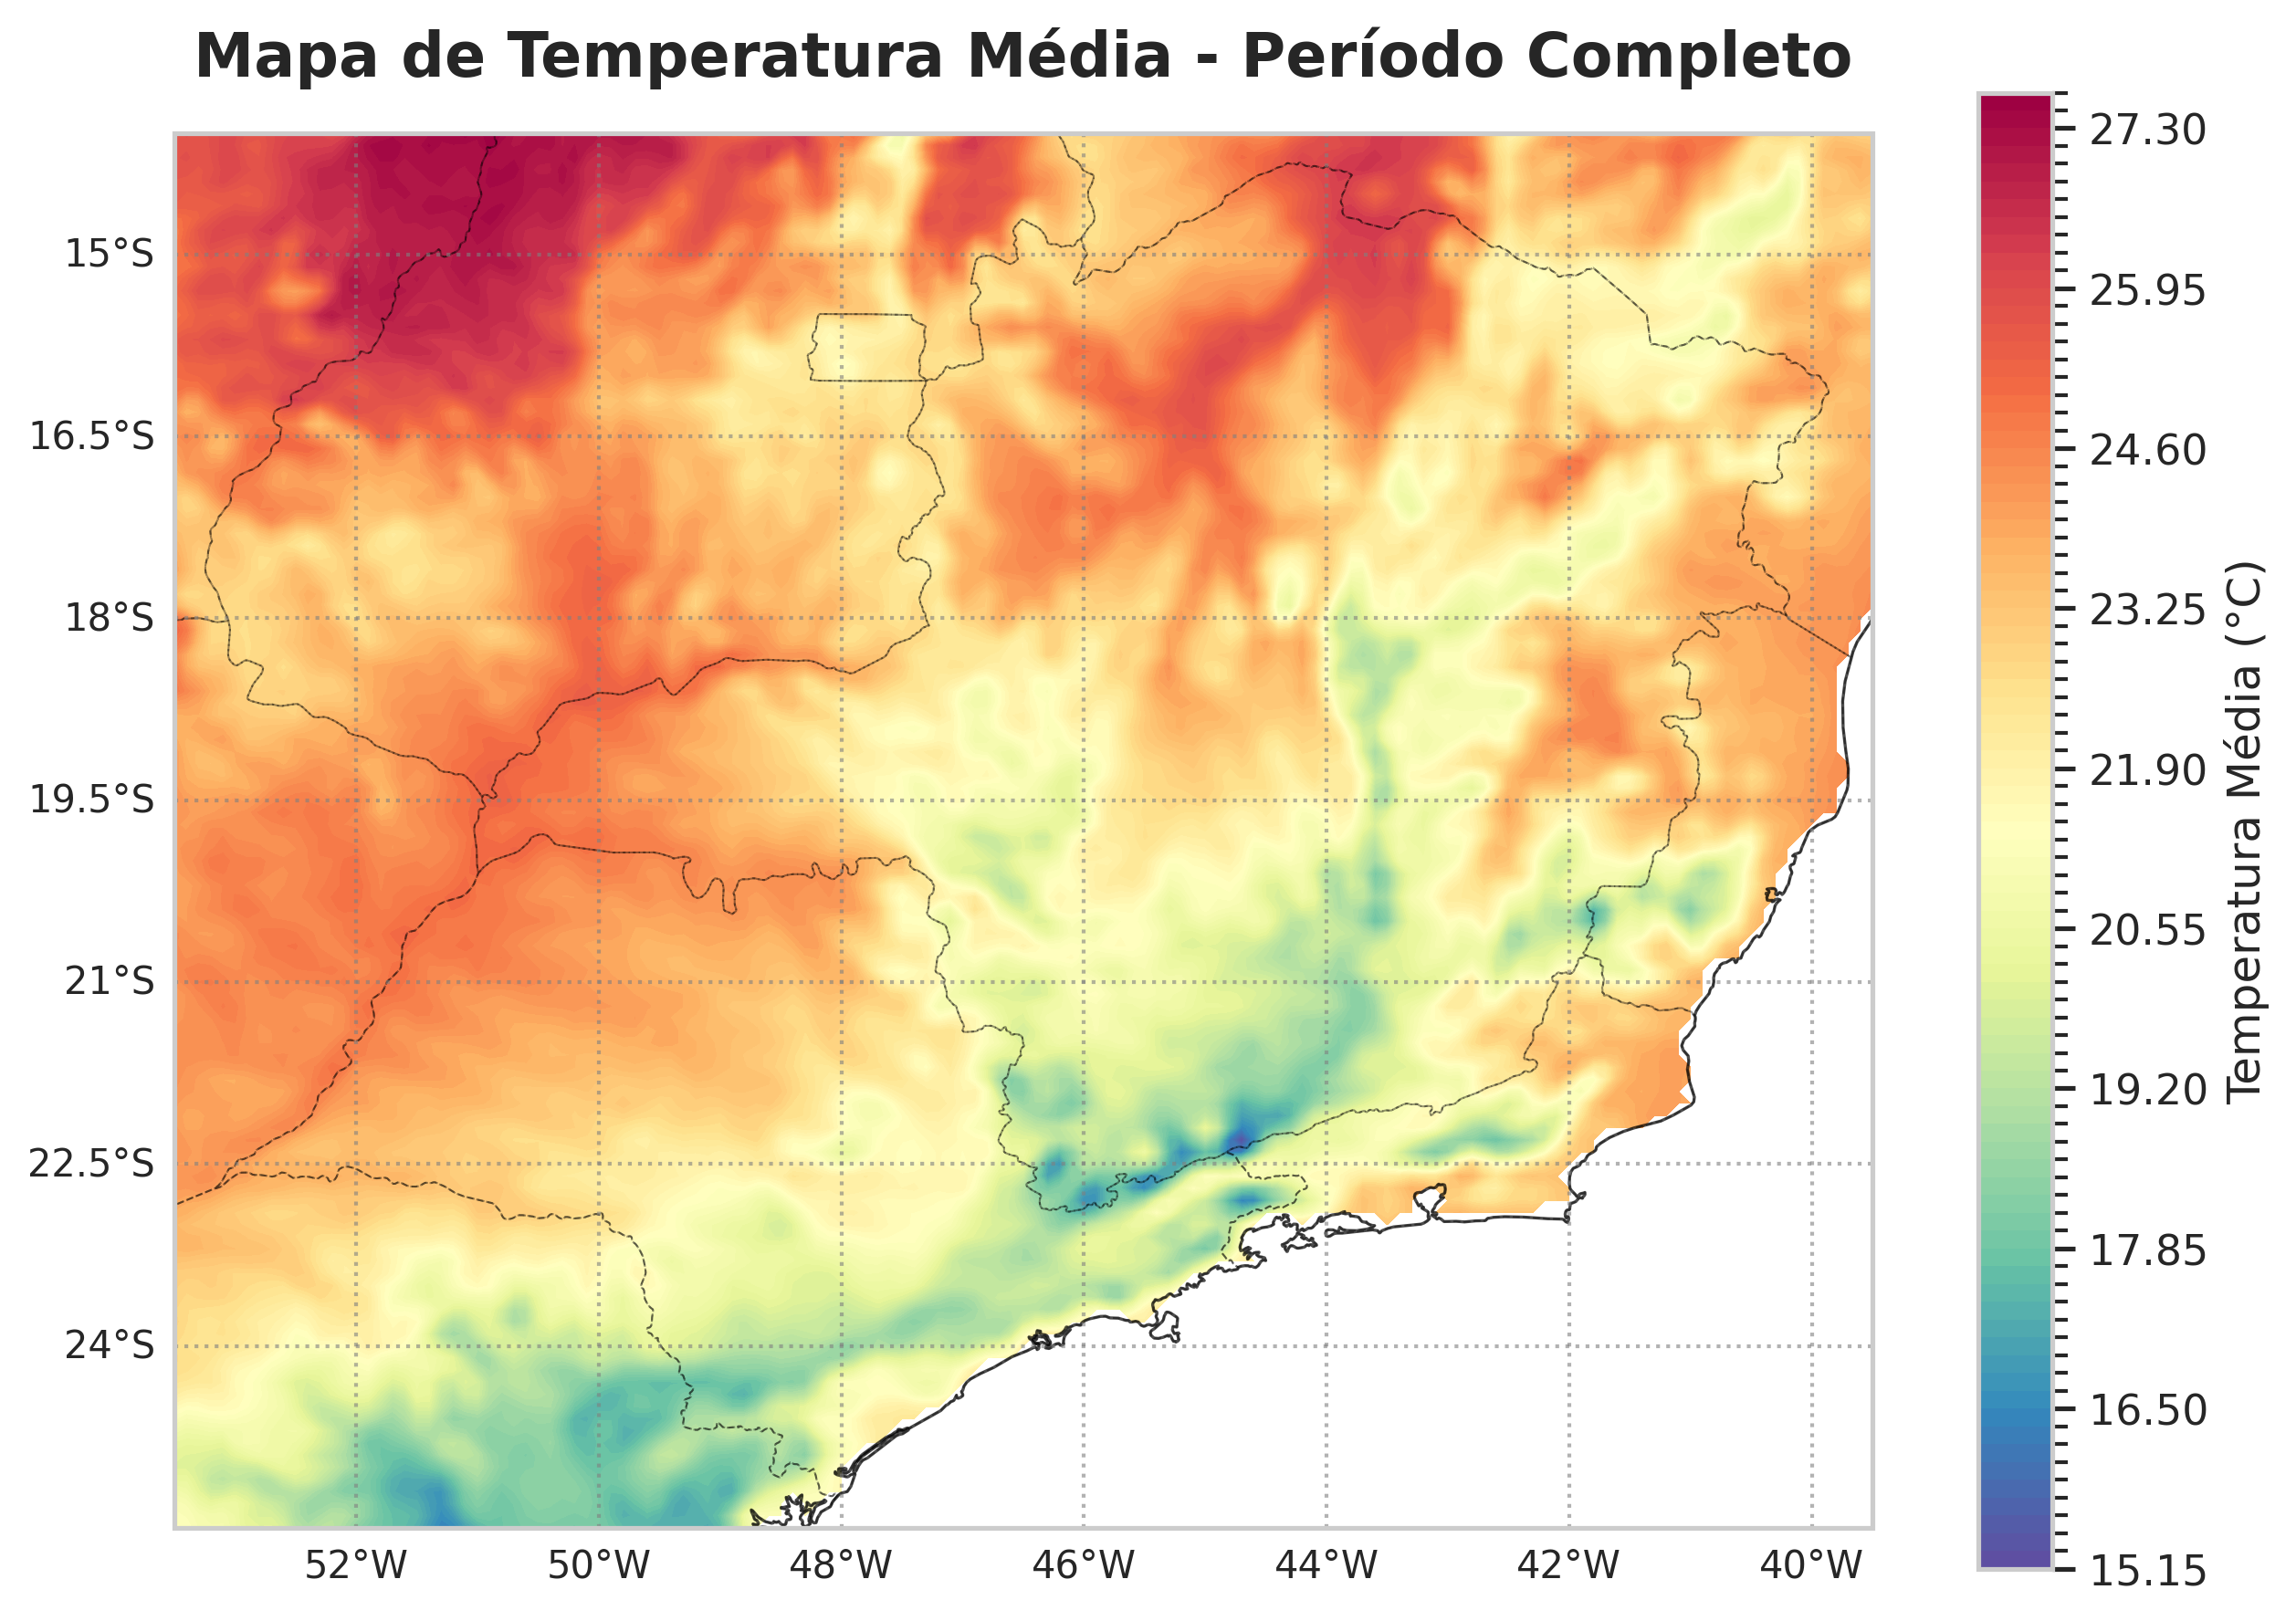

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Calcula a média espacial ao longo de TODO o período disponível no arquivo original
# Obs: Como é o arquivo todo, essa etapa pode levar alguns segundos a mais
media_espacial_completa = ds['2t'].mean(dim='forecast_reference_time')

# 2. Converte o resultado final da média de Kelvin para Celsius
media_espacial_completa = media_espacial_completa - 273.15

# 3. Configura a figura com alta resolução
fig = plt.figure(figsize=(10, 7), dpi=300)

# 4. Cria os eixos definindo que é um mapa geográfico
ax = plt.axes(projection=ccrs.PlateCarree())

# 5. Plota os dados (mesmo padrão de suavidade contourf)
media_espacial_completa.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=100,
    cmap='Spectral_r',
    cbar_kwargs={'label': 'Temperatura Média (°C)'}
)

# 6. Adiciona as delimitações territoriais (Litoral, Países e Estados)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', alpha=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black', alpha=0.7)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black', alpha=0.4, linestyle='--')

# 7. Configura as linhas de grade e as coordenadas
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.6, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Título atualizado para refletir que é o período completo
plt.title('Mapa de Temperatura Média - Período Completo', fontsize=16, fontweight='bold', pad=15)

# Salva a imagem com um nome diferente para não substituir a de 2024
plt.savefig('/content/drive/MyDrive/Dados_ERA5/mapa_alta_qualidade_completo.png', bbox_inches='tight', dpi=300)

plt.show()

/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.13/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


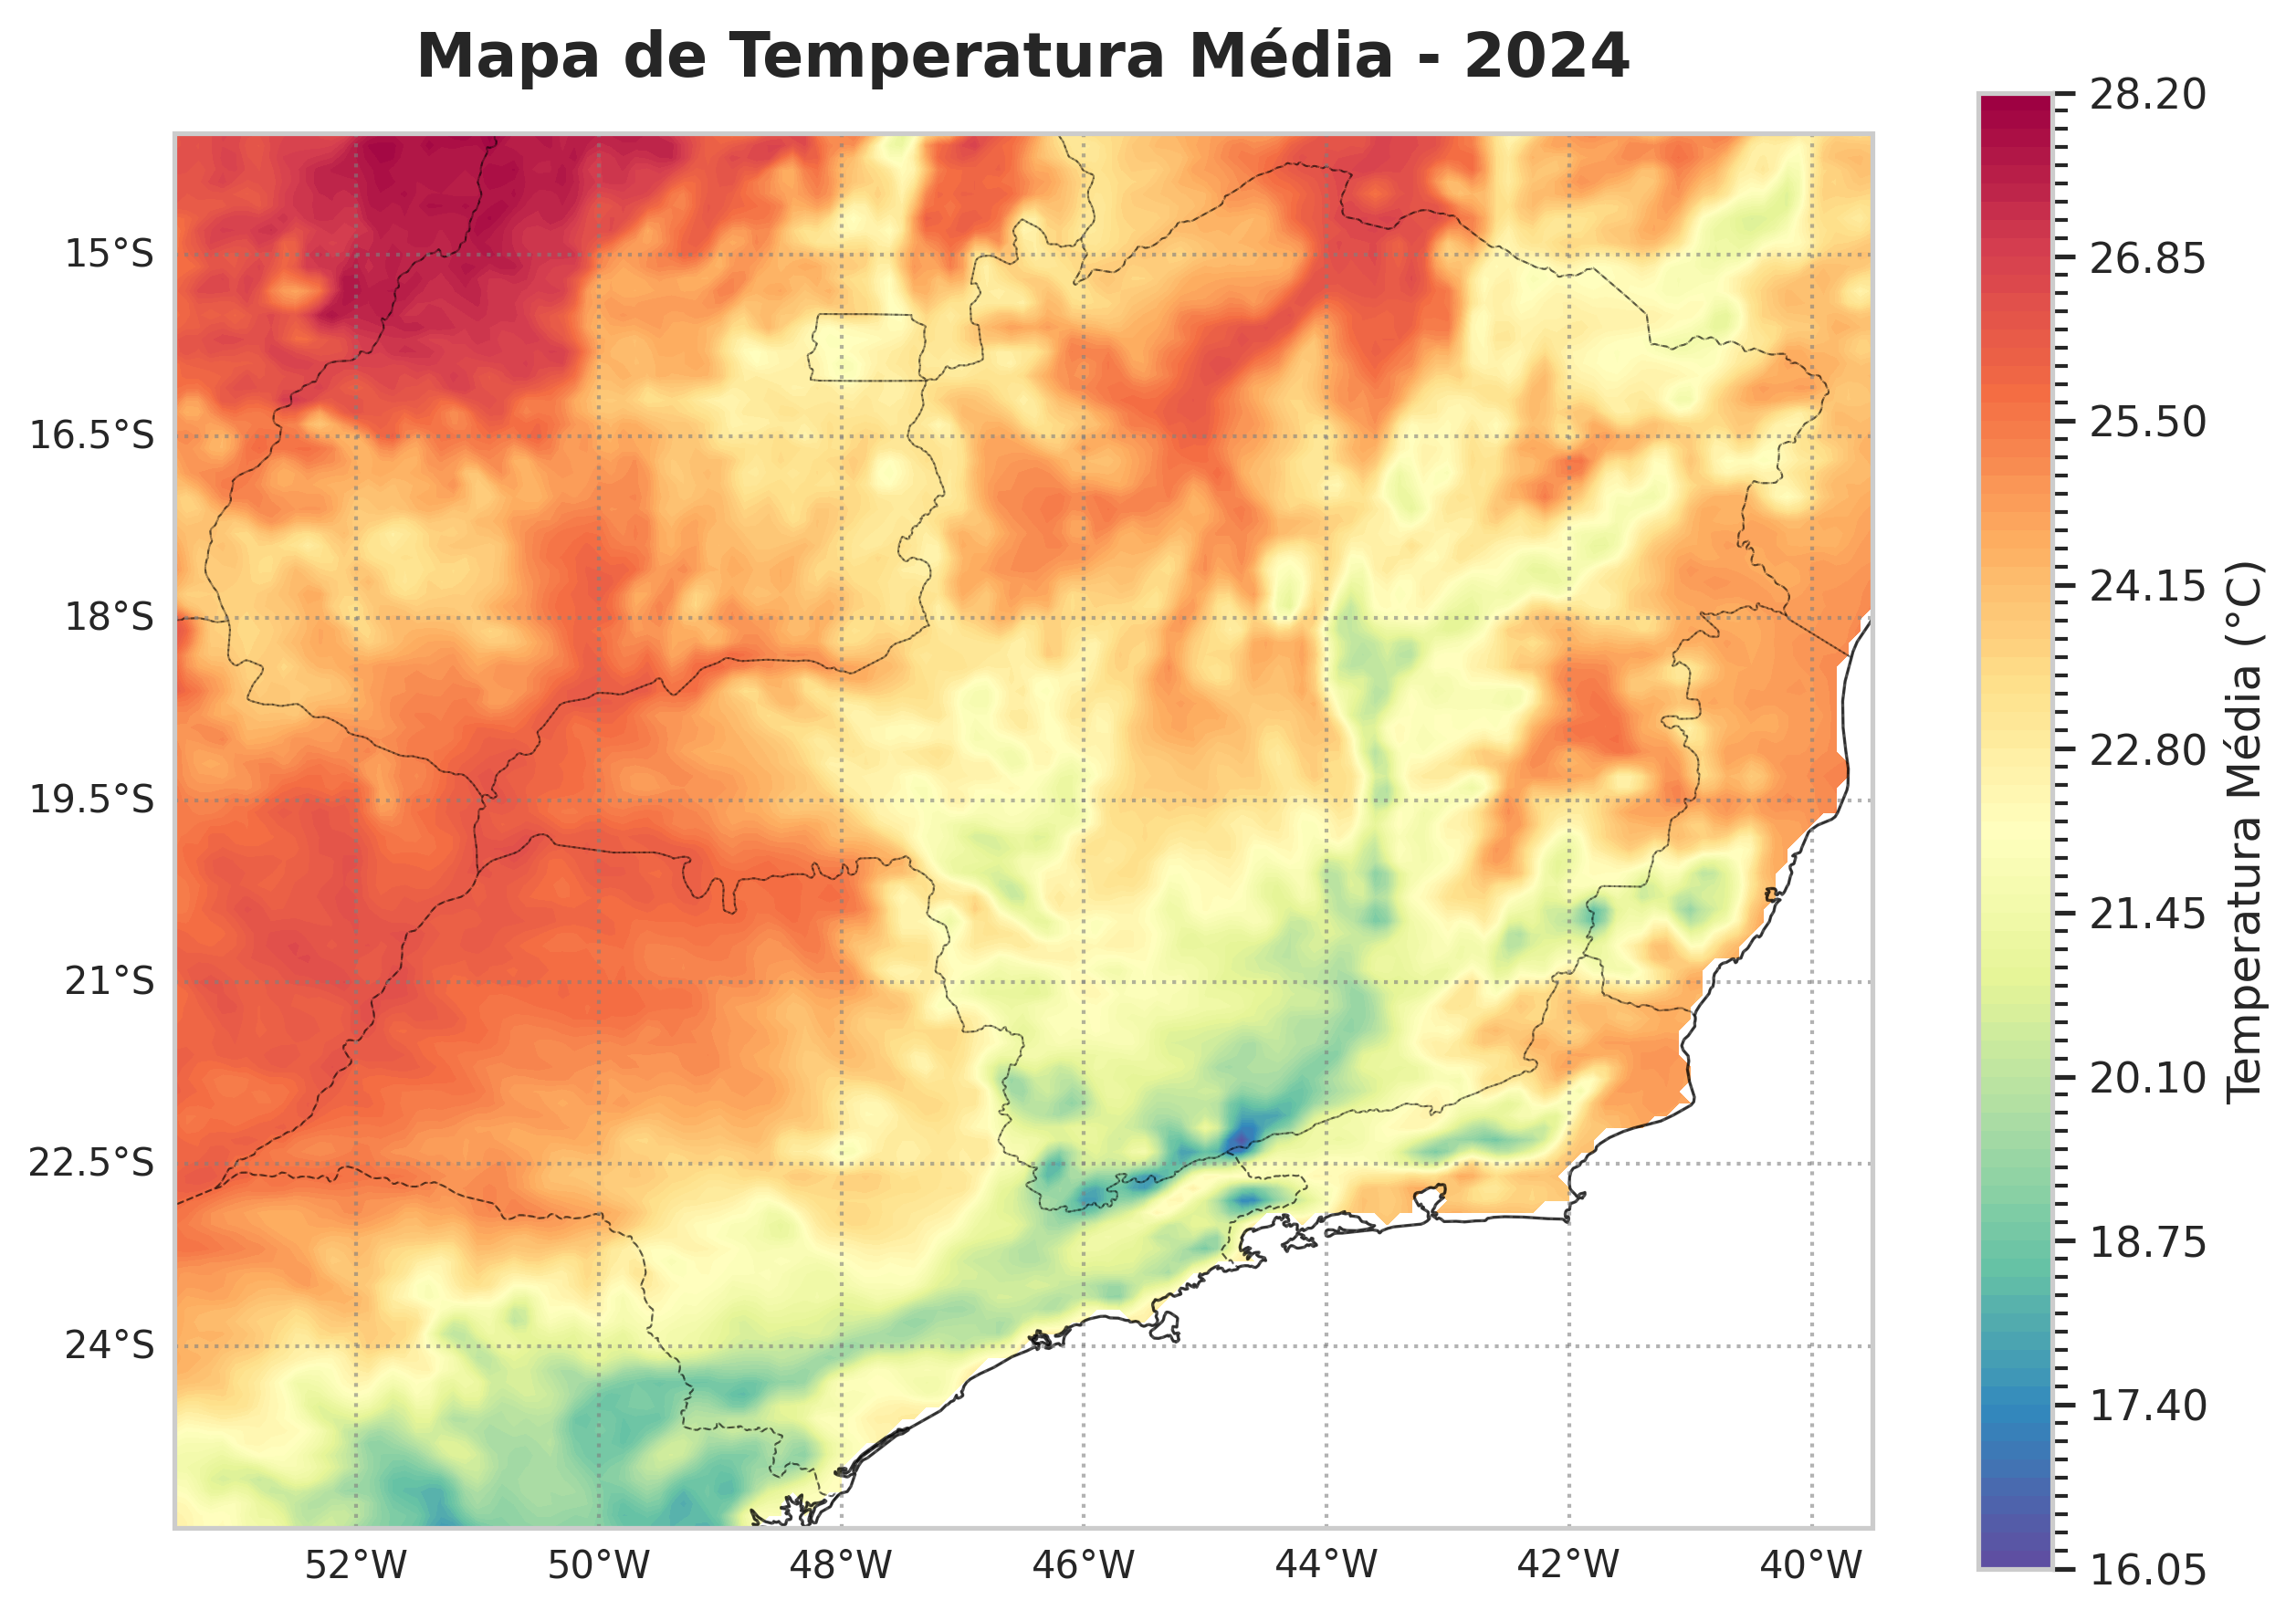

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# 1. Configura a figura com alta resolução
fig = plt.figure(figsize=(10, 7), dpi=300)

# 2. Cria os eixos definindo que é um mapa geográfico (Projeção PlateCarree)
ax = plt.axes(projection=ccrs.PlateCarree())

# 3. Plota os dados (usando ax=ax e transform para alinhar com o mapa)
media_espacial.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=100,
    cmap='Spectral_r',
    cbar_kwargs={'label': 'Temperatura Média (°C)'}
)

# 4. Adiciona as delimitações territoriais de forma suave e visível
# Litoral (Costas)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', alpha=0.7)
# Fronteiras de Países
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black', alpha=0.7)
# Divisões de Estados
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black', alpha=0.4, linestyle='--')

# 5. Configura as linhas de grade e as coordenadas (Lat/Lon)
gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.6, color='gray')
gl.top_labels = False   # Remove os números da parte de cima
gl.right_labels = False # Remove os números do lado direito
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.title('Mapa de Temperatura Média - 2024', fontsize=16, fontweight='bold', pad=15)

# Salva a imagem no Drive
plt.savefig('/content/drive/MyDrive/Dados_ERA5/mapa_alta_qualidade_fronteiras.png', bbox_inches='tight', dpi=300)

plt.show()

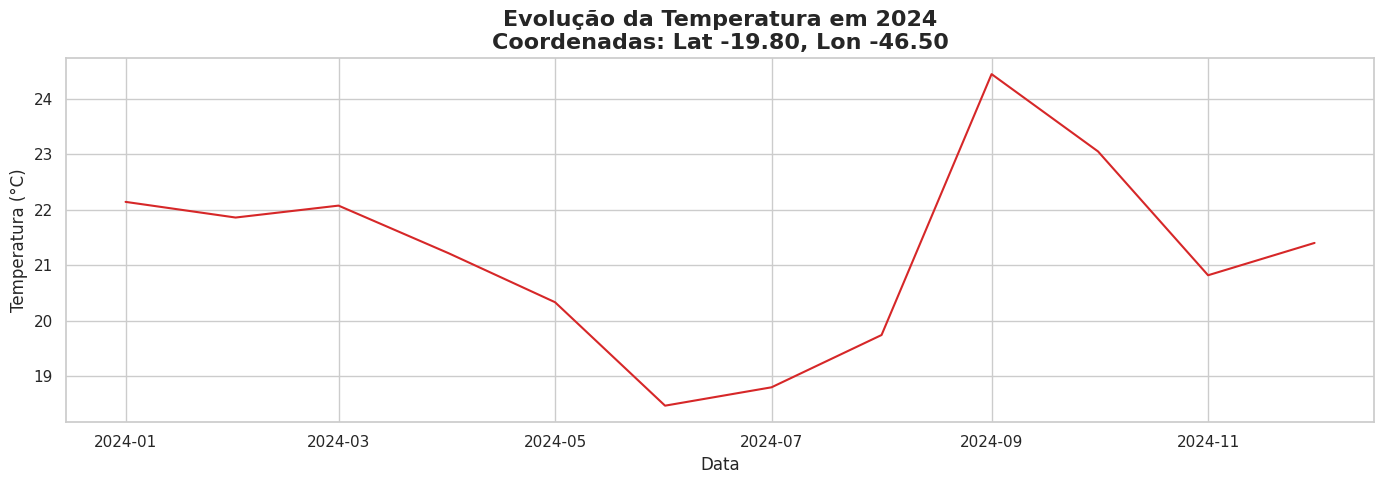

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carrega o arquivo Parquet
caminho_parquet = '/content/drive/MyDrive/Dados_ERA5/era5_temperatura_2024.parquet'
df = pd.read_parquet(caminho_parquet)

# 2. Converte Kelvin para Celsius no DataFrame
df['2t_celsius'] = df['2t'] - 273.15

# 3. Seleciona um ponto específico
# (Vamos pegar o valor mediano da sua área para garantir que existe no dado)
lat_alvo = df['latitude'].unique()[len(df['latitude'].unique()) // 2]
lon_alvo = df['longitude'].unique()[len(df['longitude'].unique()) // 2]

# Filtra o DataFrame apenas para esse ponto
df_ponto = df[(df['latitude'] == lat_alvo) & (df['longitude'] == lon_alvo)]

# 4. Configurações visuais de alta qualidade (Seaborn)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 5))

# 5. Plota a linha de evolução
sns.lineplot(
    data=df_ponto,
    x='forecast_reference_time',
    y='2t_celsius',
    color='#d62728',
    linewidth=1.5
)

plt.title(f'Evolução da Temperatura em 2024\nCoordenadas: Lat {lat_alvo:.2f}, Lon {lon_alvo:.2f}', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)

plt.tight_layout()
plt.show()